In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from itertools import combinations
import os

In [20]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

df = pd.read_csv(os.path.join(BASE_DIR, "data", "death_rate.csv"))
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               850 non-null    int64  
 1   state              850 non-null    object 
 2   hydro_gms          850 non-null    float64
 3   oxy_gms            850 non-null    float64
 4   fent_gms           850 non-null    float64
 5   log_oxy            850 non-null    float64
 6   log_hydro          850 non-null    float64
 7   log_fent           850 non-null    float64
 8   gsp                850 non-null    float64
 9   unempl_rate        850 non-null    float64
 10  min_wage           850 non-null    float64
 11  medicaid_rate      850 non-null    float64
 12  log_gsp            850 non-null    float64
 13  log_unempl_rate    850 non-null    float64
 14  log_min_wage       850 non-null    float64
 15  log_medicaid_rate  850 non-null    float64
 16  snap_rate          850 non

,year,state,hydro_gms,oxy_gms,fent_gms,log_oxy,log_hydro,log_fent,gsp,unempl_rate,...,medicaid_rate,log_gsp,log_unempl_rate,log_min_wage,log_medicaid_rate,snap_rate,poverty_rate,gov_dem,death_rate,log_death_rate
0,2000,AL,10664.777495,6724.566122,62.816442,-0.919323,-0.397068,-0.923477,120132.9,4.6,...,0.126888,-0.293286,-0.542538,-0.980485,-0.617846,-0.385960,0.205608,1,4.4857,-1.788058
1,2001,AL,11269.214757,7735.814080,62.527727,-0.837137,-0.364056,-0.925730,123035.3,5.1,...,0.150865,-0.270620,-0.236084,-0.980485,-0.166047,-0.317086,0.983944,1,4.8915,-1.628521
2,2002,AL,12882.256134,8232.095445,83.428979,-0.800658,-0.283946,-0.784388,128117.4,5.9,...,0.164526,-0.232190,0.205498,-0.980485,0.087184,-0.162924,0.564840,1,4.7619,-1.678245
3,2003,AL,14451.140460,8704.414975,103.961016,-0.767928,-0.215127,-0.676218,133969.3,6.0,...,0.166062,-0.189783,0.257058,-0.980485,0.115471,-0.033751,0.714520,0,4.4333,-1.809515
4,2004,AL,15990.254107,9164.085680,124.175547,-0.737737,-0.154520,-0.588695,146886.7,5.7,...,0.172655,-0.102385,0.100099,-0.980485,0.236452,0.077337,1.283305,0,6.3542,-1.132777


## Clustering

In [59]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Define your target years and features
years_to_check = [2000, 2008, 2016]
cluster_features = ['log_oxy', 'log_hydro', 'log_fent', 'min_wage'] # Adjust based on your actual col names
results = {}

# --- 1. Year-by-Year Clustering ---
for year in years_to_check:
    # Filter for the year
    df_year = df[df['year'] == year].copy()
    X = df_year[cluster_features]
    
    # Fit KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_year['cluster'] = kmeans.fit_predict(X)
    
    # Store results and score
    score = silhouette_score(X, df_year['cluster'])
    results[year] = {'df': df_year, 'score': score}

# --- 2. Overall Average Clustering ---
df_avg = df.groupby('state')[cluster_features].mean().reset_index()
X_avg = df_avg[cluster_features]
kmeans_avg = KMeans(n_clusters=3, random_state=42, n_init=10)
df_avg['cluster'] = kmeans_avg.fit_predict(X_avg)
results['Average'] = {'df': df_avg, 'score': silhouette_score(X_avg, df_avg['cluster'])}

# --- 3. Compare Silhouette Scores ---
for period, data in results.items():
    print(f"Silhouette Score for {period}: {data['score']:.4f}")

Silhouette Score for 2000: 0.3713
Silhouette Score for 2008: 0.3667
Silhouette Score for 2016: 0.3980
Silhouette Score for Average: 0.3371


In [60]:
# Create a pivot-style table to track movement
transitions = results[2000]['df'][['state', 'cluster']].rename(columns={'cluster': '2000'})
transitions = transitions.merge(results[2008]['df'][['state', 'cluster']].rename(columns={'cluster': '2008'}), on='state')
transitions = transitions.merge(results[2016]['df'][['state', 'cluster']].rename(columns={'cluster': '2016'}), on='state')

# Identify "Shifters" (States that changed from 2000 to 2016)
shifters = transitions[transitions['2000'] != transitions['2016']]
print("\nStates that changed risk profiles between 2000 and 2016:")
print(shifters)


States that changed risk profiles between 2000 and 2016:
   state  2000  2008  2016
0     AL     0     2     2
1     AK     2     1     1
2     AZ     0     1     1
3     AR     0     2     2
4     CA     2     2     1
5     CO     0     1     1
6     CT     2     1     1
9     GA     1     2     2
10    HI     0     1     1
11    ID     2     1     1
12    IL     0     2     2
13    IN     0     1     1
14    IA     0     1     1
16    KY     0     2     2
17    LA     0     1     1
18    ME     0     1     1
19    MD     0     1     1
20    MA     2     1     1
21    MI     0     0     1
22    MN     0     1     1
23    MS     0     1     2
24    MO     0     2     2
25    MT     0     1     1
26    NE     0     2     1
27    NV     0     1     1
28    NH     0     1     1
29    NJ     0     2     2
30    NM     0     1     1
31    NY     0     2     2
32    NC     0     0     2
33    ND     0     1     1
34    OH     0     2     2
35    OK     0     1     1
36    OR     2     1    

In [61]:
import plotly.express as px

def plot_state_map(df_results, title):
    fig = px.choropleth(
        df_results,
        locations='state', 
        locationmode="USA-states", 
        color='cluster',
        scope="usa",
        title=title,
        color_continuous_scale="Viridis" # Use discrete colors for clusters
    )
    fig.show()

# Run for each
for year in years_to_check:
    plot_state_map(results[year]['df'], f"U.S. Drug Mortality Clusters: {year}")

plot_state_map(results['Average']['df'], "Overall Average Risk Profile (1999-2016)")

In [52]:
# Define the pool based on your pre-scaled columns
# Added 'gov_dem' as it's a binary categorical often useful in policy clustering
candidate_pool = [
    'log_oxy', 'log_hydro', 'log_fent', 
    'unempl_rate', 'min_wage', 
    'log_gsp', 'snap_rate', 'log_death_rate'
]

cluster_num = 3

def find_optimal_features(df, pool, min_features=3, max_features=6):
    results = []
    # Drop NaNs just for the calculation to avoid KMeans errors
    df_calc = df[pool].dropna()
    
    print(f"Testing combinations from {min_features} to {max_features} features...")
    
    for r in range(min_features, max_features + 1):
        for combo in combinations(pool, r):
            features = list(combo)
            
            # Use k=3 as the standard benchmark
            kmeans = KMeans(n_clusters=cluster_num, random_state=42, n_init=10)
            clusters = kmeans.fit_predict(df_calc[features])
            
            score = silhouette_score(df_calc[features], clusters)
            
            results.append({
                'feature_count': r,
                'features': features,
                'silhouette': score
            })
            
    return pd.DataFrame(results).sort_values(by='silhouette', ascending=False)

# Run the search
best_combinations = find_optimal_features(df, candidate_pool)

# Display top 10 results
print("\nTop 10 Feature Sets by Silhouette Score:")
print(best_combinations.head(10))

Testing combinations from 3 to 6 features...

Top 10 Feature Sets by Silhouette Score:
    feature_count                                  features  silhouette
2               3            [log_oxy, log_hydro, min_wage]    0.459987
21              3        [log_hydro, log_fent, unempl_rate]    0.453882
7               3             [log_oxy, log_fent, min_wage]    0.449249
6               3          [log_oxy, log_fent, unempl_rate]    0.448492
22              3           [log_hydro, log_fent, min_wage]    0.432934
41              3           [log_fent, min_wage, snap_rate]    0.415276
38              3        [log_fent, unempl_rate, snap_rate]    0.409028
57              4  [log_oxy, log_hydro, log_fent, min_wage]    0.408788
31              3          [log_hydro, min_wage, snap_rate]    0.403985
0               3            [log_oxy, log_hydro, log_fent]    0.402644


In [54]:
# Create two candidate clusterings
cluster_num = 3

km_math = KMeans(n_clusters=cluster_num, random_state=42).fit_predict(df[['log_oxy', 'log_hydro', 'min_wage']])
km_comprehensive = KMeans(n_clusters=cluster_num, random_state=42).fit_predict(df[['log_oxy', 'log_hydro', 'log_fent', 'min_wage']])

df['cluster_math'] = km_math
df['cluster_comp'] = km_comprehensive

# Compare how they split the death rates
print("--- Math Winner (Set 2) ---")
print(df.groupby('cluster_math')[['log_death_rate', 'log_fent', 'log_gsp', 'min_wage']].mean())

print("\n--- Comprehensive Set (Set 57) ---")
print(df.groupby('cluster_comp')[['log_death_rate', 'log_fent', 'log_gsp', 'min_wage']].mean())

--- Math Winner (Set 2) ---
              log_death_rate  log_fent   log_gsp  min_wage
cluster_math                                              
0                   0.404810  0.141019 -0.065965  0.755045
1                  -0.623007 -0.631330 -0.238094 -0.977884
2                   0.457972  1.053282  0.658001  0.456971

--- Comprehensive Set (Set 57) ---
              log_death_rate  log_fent   log_gsp  min_wage
cluster_comp                                              
0                  -0.616031 -0.665627 -0.246180 -0.934829
1                   0.531517  1.306582  0.748016  0.466581
2                   0.384539  0.096571 -0.079604  0.731618


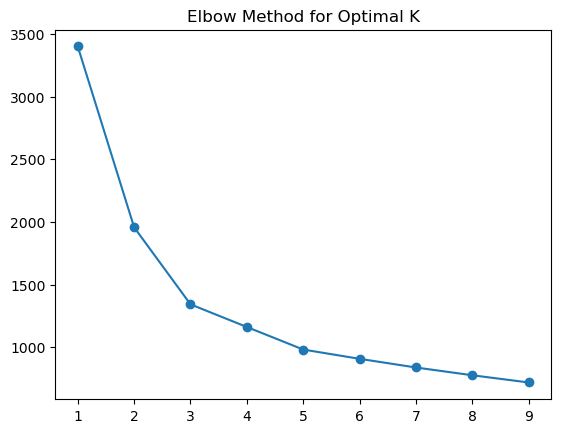

In [55]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Select the features (use the scaled versions!)
cluster_features = ['log_oxy', 'log_hydro', 'log_fent', 'min_wage']
X = df[cluster_features]

# 2. Use the "Elbow Method" to find the right number of clusters
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.show()

In [56]:
# from scipy.cluster.hierarchy import dendrogram, linkage

# # Use 'ward' linkage to minimize variance within clusters
# Z = linkage(X, method='ward')

# plt.figure(figsize=(12, 7))
# dendrogram(Z, labels=df['state'].values, leaf_rotation=90)
# plt.title('State Clusters based on Opioid Risk Factors')
# plt.show()

In [57]:
# 1. Fit the final model and grab the labels (not the distances)
kmeans_log = KMeans(n_clusters=3, random_state=42)
df['cluster_label'] = kmeans_log.fit_predict(X)  # Use fit_predict here

# view cluster summary
cluster_summary = df.groupby('cluster_label')[cluster_features].mean()
print(cluster_summary)

# see which states are in which cluster
for cluster in df['cluster_label'].unique():
    states = df[df['cluster_label'] == cluster]['state'].unique()
    print(f"States in Cluster {cluster}: {states}")

                log_oxy  log_hydro  log_fent  min_wage
cluster_label                                         
0             -0.729498  -0.656113 -0.665627 -0.934829
1              1.574869   1.624676  1.306582  0.466581
2              0.043595  -0.051483  0.096571  0.731618
States in Cluster 0: ['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'FL' 'GA' 'HI' 'ID' 'IL' 'IN'
 'IA' 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE' 'NV'
 'NH' 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD' 'TN'
 'TX' 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']
States in Cluster 1: ['AL' 'CA' 'DE' 'FL' 'GA' 'IL' 'KY' 'MD' 'MI' 'MS' 'MO' 'NJ' 'NY' 'NC'
 'OH' 'PA' 'RI' 'TN' 'UT' 'WY']
States in Cluster 2: ['AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'HI' 'ID' 'IL' 'IN' 'IA' 'KS' 'KY' 'LA'
 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MT' 'NE' 'NV' 'NH' 'NM' 'ND' 'OK' 'OR'
 'PA' 'RI' 'SC' 'SD' 'TX' 'UT' 'VT' 'VA' 'WA' 'WV' 'WI']


In [58]:
# This shows how many times each state appeared in each cluster
state_cluster_counts = df.groupby(['state', 'cluster_label']).size().unstack(fill_value=0)
print(state_cluster_counts)

cluster_label   0   1   2
state                    
AK              2   0  15
AL              6  11   0
AR              7   0  10
AZ              7   0  10
CA              6   7   4
CO              6   0  11
CT              4   0  13
DE              6  11   0
FL              6  11   0
GA              6  11   0
HI              6   0  11
IA              8   0   9
ID             10   0   7
IL              6   8   3
IN              9   0   8
KS             10   0   7
KY              8   7   2
LA              8   0   9
MA              6   0  11
MD              7   1   9
ME              6   0  11
MI              6   2   9
MN             11   0   6
MO              6  11   0
MS              8   4   5
MT              9   0   8
NC              6  11   0
ND              9   0   8
NE              6   0  11
NH              8   0   9
NJ              6  11   0
NM              9   0   8
NV              7   0  10
NY              6  11   0
OH              6  11   0
OK              8   0   9
OR          

In [31]:
import plotly.express as px

# 1. Create the 3D Scatter Plot
# Ensure you are using the unscaled original data for the plot labels!
fig = px.scatter_3d(df, x='oxy_gms', y='gsp', z='death_rate',
                    color='cluster_label', # Color points by cluster
                    text='state', # Add state abbreviations to the points
                    title='3D State Risk Profiles',
                    labels={'oxy_gms': 'Oxy supply per 100k',
                            'gsp': 'Gross State Product ($)',
                            'death_rate': 'Opioid Death Rate'},
                    opacity=0.8)

# 2. Make the markers large and clear
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

# 3. Use log scale on Oxy axis to handle the extreme outliers we saw earlier
fig.update_layout(scene=dict(xaxis=dict(type="log")))

fig.show()

In [33]:
import plotly.express as px

# 1. We need a clean mapping of Cluster Label (0, 1, 2) to names for the legend
cluster_map = {0: 'Low Risk/Stable', 1: 'Supply Epicenter (High Death)', 2: 'Economic Powerhouse (Low Death)'}
df['cluster_name'] = df['cluster_label'].map(cluster_map)

# 2. Create the Choropleth Map
fig = px.choropleth(df,
                    locations='state', # State column (must have AB codes like AL, KY, WV)
                    locationmode="USA-states", # Use built-in US map
                    color='cluster_name', # Fill colors by the cluster names we just created
                    color_discrete_sequence=["#2ca02c", "#d62728", "#ff7f0e"], # Green, Red, Orange
                    scope="usa", # Limit map to USA only
                    title='Map of State Risk Profiles (2000-2016)',
                    labels={'cluster_name': 'Risk Profile'})

# 3. Add state border lines for clarity
fig.update_layout(
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        lakecolor='rgb(255, 255, 255)'
    )
)

fig.show()

In [32]:
# Assuming 'cluster_comp' is saved in your dataframe
pd.crosstab(df['cluster_comp'], df['gov_dem'], normalize='index')

gov_dem,0,1
cluster_comp,,
0,0.571186,0.428814
1,0.538462,0.461538
2,0.487179,0.512821


In [13]:
df.columns

Index(['year', 'state', 'hydro_gms', 'oxy_gms', 'fent_gms', 'unempl_rate',
       'poverty_rate', 'gsp', 'min_wage', 'snap_rate', 'medicaid_rate',
       'gov_dem', 'death_rate', 'log_oxy', 'log_hydro', 'log_fent'],
      dtype='object')

In [21]:
feature_sets = {
    "v1_all_drugs": ['log_oxy', 'log_hydro', 'log_fent', 'snap_rate'],
    "v2_economic_focus": ['log_oxy', 'snap_rate', 'unempl_rate', 'gsp'],
    "v3_policy_risk": ['log_fent', 'snap_rate', 'min_wage', 'gov_dem']
}

def run_clustering(df, features, k=3):
    # Prepare data
    data = df[features].dropna()
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Fit Model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(scaled_data)
    
    # Score it
    score = silhouette_score(scaled_data, clusters)
    return clusters, score, data.index

# Test Version 1
features = feature_sets["v1_all_drugs"]
clusters, sil_score, idx = run_clustering(df, features, k=3)
df.loc[idx, 'cluster_v1'] = clusters

print(f"Silhouette Score for v1: {sil_score:.3f}")

# Test Version 2
features = feature_sets["v2_economic_focus"]
clusters, sil_score, idx = run_clustering(df, features, k=3)
df.loc[idx, 'cluster_v2'] = clusters

print(f"Silhouette Score for v2: {sil_score:.3f}")

# Test Version 3
features = feature_sets["v3_policy_risk"]
clusters, sil_score, idx = run_clustering(df, features, k=3)
df.loc[idx, 'cluster_v3'] = clusters

print(f"Silhouette Score for v3: {sil_score:.3f}")

Silhouette Score for v1: 0.353
Silhouette Score for v2: 0.391
Silhouette Score for v3: 0.330


In [22]:
# Group by the new clusters to see the "Story" of each group
analysis = df.groupby('cluster_v1')[['death_rate', 'snap_rate', 'log_fent', 'unempl_rate']].mean()
print(analysis)

            death_rate  snap_rate  log_fent  unempl_rate
cluster_v1                                              
0.0          -0.549637  -0.831200 -0.606349    -0.508373
1.0           0.451996   0.728684  1.308332     0.732757
2.0           0.422771   0.618974  0.101041     0.249035


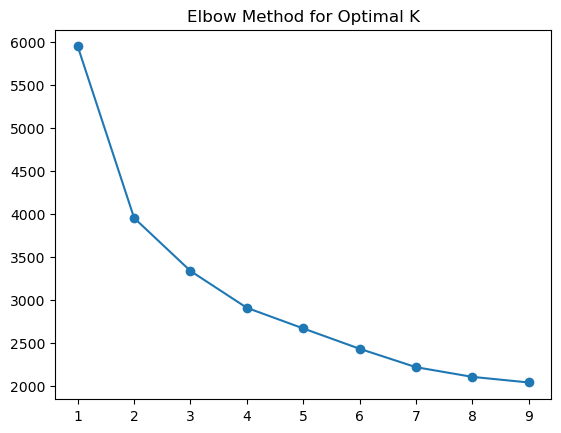

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Select the features (use the scaled versions!)
cluster_features = ['log_oxy', 'log_hydro', 'log_fent', 'unempl_rate', 'snap_rate',
                    'gsp', 'death_rate']
X = df[cluster_features]

# 2. Use the "Elbow Method" to find the right number of clusters
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.show()

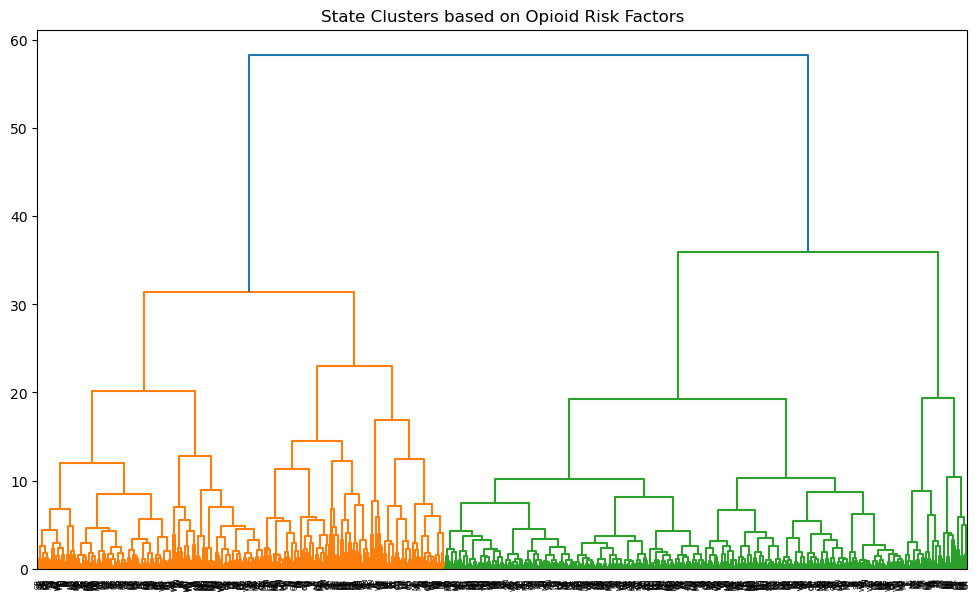

In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Use 'ward' linkage to minimize variance within clusters
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z, labels=df['state'].values, leaf_rotation=90)
plt.title('State Clusters based on Opioid Risk Factors')
plt.show()

In [16]:
# 1. Fit the final model and grab the labels (not the distances)
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster_label'] = kmeans.fit_predict(X)  # Use fit_predict here

# view cluster summary
cluster_summary = df.groupby('cluster_label')[cluster_features].mean()
print(cluster_summary)

# see which states are in which cluster
for cluster in df['cluster_label'].unique():
    states = df[df['cluster_label'] == cluster]['state'].unique()
    print(f"States in Cluster {cluster}: {states}")

                log_oxy  log_hydro  log_fent  unempl_rate  snap_rate  \
cluster_label                                                          
0              0.129683   0.081578  0.120370     0.476310   0.757297   
1              1.735162   1.665388  1.463334     0.728611   0.788748   
2             -0.584958  -0.611316 -0.504263    -0.547874  -0.697835   
3              0.087072   0.917642  0.118768     0.493188   0.048244   

                    gsp  death_rate  
cluster_label                        
0             -0.262783    0.759515  
1              0.344082    0.496943  
2             -0.272545   -0.571706  
3              3.672773   -0.431608  
States in Cluster 2: ['AL' 'AK' 'AZ' 'AR' 'CO' 'CT' 'DE' 'FL' 'GA' 'HI' 'ID' 'IL' 'IN' 'IA'
 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT' 'NE' 'NV' 'NH'
 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'RI' 'SC' 'SD' 'TN' 'TX'
 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']
States in Cluster 0: ['AL' 'AK' 'AZ' 'AR' 'CO' 'CT' 'HI' 'ID' 'IL' '

In [17]:
import plotly.express as px

# 1. Create the 3D Scatter Plot
# Ensure you are using the unscaled original data for the plot labels!
fig = px.scatter_3d(df, x='oxy_gms', y='poverty_rate', z='death_rate',
                    color='cluster_label', # Color points by cluster
                    text='state', # Add state abbreviations to the points
                    title='3D State Risk Profiles',
                    labels={'oxy_gms': 'Oxy supply per 100k',
                            'poverty_rate': 'Poverty Rate (%)',
                            'death_rate': 'Opioid Death Rate'},
                    opacity=0.8)

# 2. Make the markers large and clear
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

# 3. Use log scale on Oxy axis to handle the extreme outliers we saw earlier
fig.update_layout(scene=dict(xaxis=dict(type="log")))

fig.show()

In [45]:
import plotly.express as px

# 1. We need a clean mapping of Cluster Label (0, 1, 2) to names for the legend
cluster_map = {0: 'Low Risk/Stable', 1: 'Supply Epicenter (High Death)', 2: 'Economic Vulnerability'}
df['cluster_name'] = df['cluster_label'].map(cluster_map)

# 2. Create the Choropleth Map
fig = px.choropleth(df,
                    locations='state', # State column (must have AB codes like AL, KY, WV)
                    locationmode="USA-states", # Use built-in US map
                    color='cluster_name', # Fill colors by the cluster names we just created
                    color_discrete_sequence=["#2ca02c", "#d62728", "#ff7f0e"], # Green, Red, Orange
                    scope="usa", # Limit map to USA only
                    title='Map of State Risk Profiles (2000-2016)',
                    labels={'cluster_name': 'Risk Profile'})

# 3. Add state border lines for clarity
fig.update_layout(
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        lakecolor='rgb(255, 255, 255)'
    )
)

fig.show()